# Mixed-Precision Greedy Bit-Budget Allocator Benchmark

Connects **data-free layer scores** (+ InfoQ) to a **sensitivity-guided greedy bit allocator** under target average bit-widths.

**Allocation protocol (NSDS / HAWQ / Schaefer et al. Algorithm 2):**
1. Start all layers at `b_min` (lowest bit on the ladder).
2. Sort layers by sensitivity descending (most sensitive first).
3. For each layer in order, upgrade it as high on the ladder `{2,3,4,8}` as the budget allows.

This ensures high-sensitivity layers receive more bits and **different score rankings produce different bit mixes at every target** — unlike the two-level scheme which ties methods at many targets.

**Benchmarks:** CIFAR-100 ResNet/ViT · ImageNet ResNet/ViT · Qwen 1.5B WikiText-2 PPL

**Targets:** avg bits ∈ {2.5, 3.0, 3.5, 4.0} · **Ladder:** {2,3,4,8} for vision; {3,4,8} for LLM

Implementation: `bit_budget_allocator.py → greedy_allocate_bits()`


In [1]:
!pip install -q torchvision scikit-learn datasets transformers accelerate



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [18]:
from __future__ import annotations

import copy
import math
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from datasets import load_dataset
from PIL import Image
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import importlib
import bit_budget_allocator as _bit_budget_allocator
importlib.reload(_bit_budget_allocator)

from bit_budget_allocator import (
    ALLOCATOR_METHODS,
    LLM_BITS_LOW,
    LLM_LADDER,
    METHOD_TO_COL,
    PROTECT_BITS_DEFAULT,
    VISION_BITS_LOW,
    VISION_LADDER,
    allocate_from_score_df,
    assignment_avg_bits,
    bits_low_for_mixing,
    compute_data_free_scores,
    load_or_enrich_scores,
    greedy_random_baseline,
    infoq_scores,
    nearest_uniform_bits,
    quantize_model_per_layer,
    random_score,
    summarize_bit_mix,
    uniform_layer_bits,
    uniform_two_level_baseline,
)
from layer_importance_quant import param_count as param_count_fn, quantize_weights

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 9})

ROOT = Path('.').resolve()
OUT_DIR = ROOT / 'results' / 'proportional_mp_allocator'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_AVG_BITS = [2.5, 3.0, 3.5, 4.0]
QWEN_TARGET_AVG_BITS = [*TARGET_AVG_BITS, 4.5, 5.0]  # LLM-only extra targets
PROTECT_BITS = PROTECT_BITS_DEFAULT
METHODS = list(ALLOCATOR_METHODS)

SEED = 42
BATCH_SIZE = 64
NUM_WORKERS = 0
RANDOM_SEED = SEED

# ImageNet split — must match imagenet_layer_importance_benchmark.ipynb
IMAGENET_CALIB_N = 512
IMAGENET_TRAIN_FRAC = 0.85
IMAGENET_VAL_FRAC = 0.05

# Toggle benchmarks
RUN_CIFAR100 = True
RUN_IMAGENET = True
RUN_QWEN = True
RUN_INFOQ = False          # needs calib batch; slow on LLM

SMOKE_TEST = True
IMAGENET_EVAL_N = 512 if SMOKE_TEST else 2000
QWEN_EVAL_TOKENS = 8_192 if SMOKE_TEST else None

FORCE_RECOMPUTE = False

CIFAR100_ROOT = Path(os.environ.get('CIFAR100_ROOT', str(ROOT / 'data' / 'cifar100')))
CKPT_CIFAR = ROOT / 'checkpoints_cifar100'
IMAGENET_ROOTS = [p for p in [
    Path(os.environ.get('IMAGENET_ROOT', '/Users/nathan/Downloads/ImageNet')),
    Path(os.environ.get('IMAGENET_ROOT2', '/Users/nathan/Downloads/ImageNet2')),
] if p.exists()]
CKPT_IMAGENET = ROOT / 'checkpoints_imagenet'
QWEN_PATH = '/Users/nathan/qwen1.5b'

torch.manual_seed(SEED)
np.random.seed(SEED)
os.environ.setdefault('HF_HOME', str(ROOT / '.hf_cache'))

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')
print(f'OUT_DIR: {OUT_DIR}')
print(f'Targets: {TARGET_AVG_BITS} | Qwen targets: {QWEN_TARGET_AVG_BITS} | Methods: {METHODS}')
print(f'SMOKE_TEST={SMOKE_TEST}')


Device: mps
OUT_DIR: /Users/nathan/Documents/bruh4/results/proportional_mp_allocator
Targets: [2.5, 3.0, 3.5, 4.0] | Qwen targets: [2.5, 3.0, 3.5, 4.0, 4.5, 5.0] | Methods: ['pct', 'old', 'entropy', 'sea', 'spectral_pct', 'spectral_top10', 'nsds', 'infoq', 'random']
SMOKE_TEST=True


In [3]:
# ── Shared vision helpers ───────────────────────────────────────────────────────

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
NUM_CLASSES_CIFAR = 100
NUM_CLASSES_IMAGENET = 1000
VIT_IMAGE_SIZE = 224


def get_module(model: nn.Module, name: str) -> nn.Module:
    m = model
    for p in name.split('.'):
        m = getattr(m, p)
    return m


def discover_quant_layers(model: nn.Module) -> list[str]:
    return [n for n, mod in model.named_modules() if n and isinstance(mod, (nn.Conv2d, nn.Linear))]


def get_resnet18_cifar(num_classes: int = NUM_CLASSES_CIFAR) -> nn.Module:
    m = torchvision.models.resnet18(weights=None, num_classes=num_classes)
    m.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    return m


def build_model_cifar(arch: str) -> nn.Module:
    """Architecture scaffold only — all weights loaded from CIFAR checkpoint."""
    if arch == 'resnet18':
        return get_resnet18_cifar()
    if arch == 'vit_b16':
        m = torchvision.models.vit_b_16(weights=None)
        m.heads.head = nn.Linear(m.heads.head.in_features, NUM_CLASSES_CIFAR)
        return m
    raise ValueError(arch)


def get_resnet18_imagenet() -> nn.Module:
    cache = CKPT_IMAGENET / 'resnet18_imagenet1k_v1.pt'
    if not cache.exists():
        raise FileNotFoundError(f'Missing {cache} — cache ImageNet weights locally, no auto-download')
    m = torchvision.models.resnet18(weights=None)
    m.load_state_dict(torch.load(cache, map_location='cpu', weights_only=True))
    return m


def get_vit_b16_imagenet() -> nn.Module:
    cache = CKPT_IMAGENET / 'vit_b16_imagenet1k_v1.pt'
    if not cache.exists():
        raise FileNotFoundError(f'Missing {cache} — cache ImageNet weights locally, no auto-download')
    m = torchvision.models.vit_b_16(weights=None)
    m.load_state_dict(torch.load(cache, map_location='cpu', weights_only=True))
    return m


@torch.no_grad()
def collect_probs(model: nn.Module, loader) -> tuple[torch.Tensor, torch.Tensor]:
    m = model.to(DEVICE).eval()
    probs, labels = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        logits = m(x)
        probs.append(torch.softmax(logits.float(), dim=1).cpu())
        labels.append(y)
    return torch.cat(probs), torch.cat(labels)


def calibration_metrics(probs: torch.Tensor, labels: torch.Tensor) -> dict:
    conf, pred = probs.max(dim=1)
    corr = (pred == labels).numpy().astype(np.float64)
    oh = F.one_hot(labels.long(), num_classes=probs.shape[1]).float()
    return {
        'accuracy': float(corr.mean()),
        'f1': float(f1_score(labels.numpy(), pred.numpy(), average='macro')),
        'nll': float(F.nll_loss(torch.log(probs.clamp(min=1e-12)), labels.long()).item()),
    }


def evaluate_accuracy(model: nn.Module, loader) -> dict:
    probs, labels = collect_probs(model, loader)
    return calibration_metrics(probs, labels)


def load_cifar_checkpoint(arch: str) -> nn.Module:
    ckpt = CKPT_CIFAR / f'{arch}_cifar100_best_valacc.pt'
    if not ckpt.exists():
        raise FileNotFoundError(f'Missing {ckpt} — train cifar100_layer_importance_benchmark.ipynb first')
    meta = torch.load(ckpt, map_location='cpu', weights_only=False)
    m = build_model_cifar(arch)
    m.load_state_dict(meta['state_dict'], strict=True)
    m = m.eval().cpu()
    te = meta.get('test_metrics', {})
    acc = te.get('accuracy', meta.get('test_acc'))
    if acc is not None:
        print(f'Loaded {arch} from {ckpt.name} | CIFAR-100 test acc={float(acc)*100:.2f}%')
    else:
        print(f'Loaded {arch} from {ckpt.name}')
    return m


print('Vision helpers ready.')


Vision helpers ready.


In [4]:
# ── CIFAR-100 loaders (local only, no download) ───────────────────────────────

class CIFAR100Local(datasets.CIFAR100):
    """Read unpacked cifar-100-python batches from CIFAR100_ROOT (train/test/meta files)."""
    base_folder = '.'


CIFAR_TRANSFORM = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])
CIFAR_VIT_TRANSFORM = transforms.Compose([
    transforms.Resize((VIT_IMAGE_SIZE, VIT_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def make_cifar_loaders():
    if not CIFAR100_ROOT.exists():
        raise FileNotFoundError(f'CIFAR-100 root missing: {CIFAR100_ROOT}')
    full = CIFAR100Local(str(CIFAR100_ROOT), train=True, download=False, transform=CIFAR_TRANSFORM)
    test = CIFAR100Local(str(CIFAR100_ROOT), train=False, download=False, transform=CIFAR_TRANSFORM)
    vit_test = CIFAR100Local(str(CIFAR100_ROOT), train=False, download=False, transform=CIFAR_VIT_TRANSFORM)
    vit_calib_base = CIFAR100Local(str(CIFAR100_ROOT), train=True, download=False, transform=CIFAR_VIT_TRANSFORM)
    rng = np.random.RandomState(SEED)
    perm = rng.permutation(len(full))
    calib_idx = perm[:512].tolist()
    kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == 'cuda')
    calib_loader = DataLoader(Subset(full, calib_idx), shuffle=False, **kwargs)
    vit_calib_loader = DataLoader(Subset(vit_calib_base, calib_idx), shuffle=False, **kwargs)
    test_loader = DataLoader(test, shuffle=False, **kwargs)
    vit_test_loader = DataLoader(vit_test, shuffle=False, **kwargs)
    print(f'CIFAR-100 local | train={len(full)} test={len(test)} calib={len(calib_idx)}')
    return calib_loader, vit_calib_loader, test_loader, vit_test_loader


if RUN_CIFAR100:
    cifar_calib, cifar_vit_calib, cifar_test_loader, cifar_vit_test_loader = make_cifar_loaders()


CIFAR-100 local | train=50000 test=10000 calib=512


In [5]:
# ── ImageNet loaders (same split as imagenet_layer_importance_benchmark) ─────

_IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


class NumericFolderDataset(Dataset):
    def __init__(self, roots: list[Path], transform=None):
        self.transform = transform
        self.samples: list[tuple[str, int]] = []
        for root in roots:
            root = Path(root)
            if not root.is_dir():
                continue
            for cls_dir in sorted(p for p in root.iterdir() if p.is_dir()):
                try:
                    label = int(cls_dir.name)
                except ValueError:
                    continue
                for img in cls_dir.iterdir():
                    if img.is_file() and img.suffix.lower() in _IMG_EXTS:
                        self.samples.append((str(img), label))
        if not self.samples:
            raise ValueError(f'No images found under {roots}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, y = self.samples[idx]
        x = Image.open(path).convert('RGB')
        if self.transform:
            x = self.transform(x)
        return x, y


def _is_flat_numeric_roots(roots: list[Path]) -> bool:
    if not roots:
        return False
    for root in roots:
        if not Path(root).is_dir():
            return False
        if (Path(root) / 'train').is_dir() or (Path(root) / 'val').is_dir():
            return False
    return True


IMAGENET_EVAL_TF = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def make_imagenet_loaders():
    """Held-out test pool split — NOT random 512 from all 626k images."""
    if not IMAGENET_ROOTS:
        raise FileNotFoundError('ImageNet roots not found — set IMAGENET_ROOT')
    kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == 'cuda')

    if _is_flat_numeric_roots(IMAGENET_ROOTS):
        n = len(NumericFolderDataset(IMAGENET_ROOTS))
        need_test = IMAGENET_EVAL_N + IMAGENET_CALIB_N
        n_test = max(need_test, int(n * (1.0 - IMAGENET_TRAIN_FRAC - IMAGENET_VAL_FRAC)))
        n_val = max(1, int(n * IMAGENET_VAL_FRAC))
        n_train = n - n_val - n_test
        if n_train < 1:
            raise ValueError(f'Not enough images ({n}) for split')

        rng = np.random.RandomState(RANDOM_SEED)
        perm = rng.permutation(n)
        test_idx = perm[n_train + n_val:].tolist()
        test_pool = list(test_idx)
        rng.shuffle(test_pool)
        eval_idx = test_pool[:IMAGENET_EVAL_N]
        calib_idx = test_pool[IMAGENET_EVAL_N:IMAGENET_EVAL_N + IMAGENET_CALIB_N]

        test_base = NumericFolderDataset(IMAGENET_ROOTS, IMAGENET_EVAL_TF)
        test_loader = DataLoader(Subset(test_base, eval_idx), shuffle=False, **kwargs)
        calib_loader = DataLoader(Subset(test_base, calib_idx), shuffle=False, **kwargs)
        print(f'ImageNet flat folders | total={n} test_pool={len(test_idx)} eval={len(eval_idx)} calib={len(calib_idx)}')
        return calib_loader, test_loader

    # ILSVRC train/val layout fallback
    root = IMAGENET_ROOTS[0]
    val_full = datasets.ImageFolder(str(root / 'val'), transform=IMAGENET_EVAL_TF) \
        if (root / 'val').is_dir() else \
        datasets.ImageNet(str(root), split='val', transform=IMAGENET_EVAL_TF)
    test_loader = DataLoader(Subset(val_full, range(min(IMAGENET_EVAL_N, len(val_full)))), shuffle=False, **kwargs)
    calib_loader = DataLoader(Subset(val_full, range(IMAGENET_EVAL_N, min(IMAGENET_EVAL_N + IMAGENET_CALIB_N, len(val_full)))), shuffle=False, **kwargs)
    print(f'ImageNet val split | eval={len(test_loader.dataset)} calib={len(calib_loader.dataset)}')
    return calib_loader, test_loader


if RUN_IMAGENET:
    imagenet_calib, imagenet_test_loader = make_imagenet_loaders()


ImageNet flat folders | total=626000 test_pool=62600 eval=512 calib=512


In [6]:
# ── Score + allocate + evaluate (vision) ──────────────────────────────────────

# load_or_enrich_scores lives in bit_budget_allocator.py
# Legacy CSVs are preferred; only spectral_top10 is computed if missing.


def run_vision_allocator_benchmark(
    model, layer_names, test_loader, calib_loader,
    bench_name: str, score_cache: Path, legacy_caches: list[Path] | None = None,
    ladder: tuple[int, ...] = VISION_LADDER,
) -> pd.DataFrame:
    param_counts = param_count_fn(model, layer_names, get_module)
    calib_batch = next(iter(calib_loader)) if RUN_INFOQ else None
    score_df = load_or_enrich_scores(
        model, layer_names, get_module, score_cache, legacy_caches,
        bench_tag=bench_name, force_recompute=FORCE_RECOMPUTE,
        run_infoq=RUN_INFOQ, calib_batch=calib_batch, device=DEVICE,
        random_seed=RANDOM_SEED,
    )

    # FP32 reference
    fp_met = evaluate_accuracy(model, test_loader)
    rows = [{
        'benchmark': bench_name, 'method': 'fp32', 'target_avg_bits': np.nan,
        'avg_bits': 32.0, 'accuracy': fp_met['accuracy'], 'f1': fp_met['f1'],
        'nll': fp_met['nll'], 'bit_mix': 'FP32',
    }]

    results_cache = OUT_DIR / f'{bench_name}_allocator_results.csv'

    def _save(df: pd.DataFrame) -> pd.DataFrame:
        df.to_csv(results_cache, index=False)
        return df

    if results_cache.exists() and not FORCE_RECOMPUTE:
        cached = pd.read_csv(results_cache)
        if set(cached['target_avg_bits'].dropna().unique()) >= set(TARGET_AVG_BITS):
            print(f'  Loaded allocator results: {results_cache.name}')
            return cached

    for target in TARGET_AVG_BITS:
        # Greedy random baseline: same ladder but random ordering
        u_assign = greedy_random_baseline(layer_names, param_counts, target,
                                          ladder=ladder, seed=RANDOM_SEED)
        avg_u = assignment_avg_bits(layer_names, param_counts, u_assign)
        mq = quantize_model_per_layer(model, layer_names, get_module, u_assign)
        met = evaluate_accuracy(mq, test_loader)
        rows.append({
            'benchmark': bench_name, 'method': 'greedy_random',
            'target_avg_bits': target,
            'avg_bits': avg_u, 'accuracy': met['accuracy'], 'f1': met['f1'],
            'nll': met['nll'], 'bit_mix': summarize_bit_mix(u_assign),
        })

        for method in METHODS:
            col = METHOD_TO_COL[method]
            if col not in score_df.columns or score_df[col].isna().all():
                continue
            layer_bits = allocate_from_score_df(
                score_df, method, layer_names, param_counts, target,
                ladder=ladder,
            )
            avg_b = assignment_avg_bits(layer_names, param_counts, layer_bits)
            mq = quantize_model_per_layer(model, layer_names, get_module, layer_bits)
            met = evaluate_accuracy(mq, test_loader)
            rows.append({
                'benchmark': bench_name, 'method': method,
                'target_avg_bits': target, 'avg_bits': avg_b,
                'accuracy': met['accuracy'], 'f1': met['f1'], 'nll': met['nll'],
                'bit_mix': summarize_bit_mix(layer_bits),
            })
            print(f'  {bench_name} target={target} {method:14s} avg={avg_b:.2f} acc={met["accuracy"]*100:.2f}%')

        _save(pd.DataFrame(rows))  # incremental save after each target

    df = _save(pd.DataFrame(rows))
    print(f'  Saved -> {results_cache} ({len(df)} rows)')
    return df


print('Vision allocator runner ready.')


Vision allocator runner ready.


In [7]:
# ── Run CIFAR-100 ─────────────────────────────────────────────────────────────

cifar100_results: list[pd.DataFrame] = []

if RUN_CIFAR100:
    for arch, tag, test_ldr, calib_ldr in [
        ('resnet18', 'cifar100_resnet', cifar_test_loader, cifar_calib),
        ('vit_b16', 'cifar100_vit', cifar_vit_test_loader, cifar_vit_calib),
    ]:
        print(f'\n{"="*72}\n{tag}\n{"="*72}')
        m = load_cifar_checkpoint(arch)
        lnames = discover_quant_layers(m)
        cache = OUT_DIR / f'{tag}_scores.csv'
        legacy = [ROOT / 'results' / 'cifar100_layer_importance_benchmark' / 'resnet_cifar100_scores.csv'] if arch == 'resnet18' else [ROOT / 'results' / 'cifar100_layer_importance_benchmark' / 'vit_cifar100_scores.csv']
        df = run_vision_allocator_benchmark(m, lnames, test_ldr, calib_ldr, tag, cache, legacy)
        cifar100_results.append(df)

cifar100_all = pd.concat(cifar100_results, ignore_index=True) if cifar100_results else pd.DataFrame()
if len(cifar100_all):
    cifar100_all.to_csv(OUT_DIR / 'cifar100_allocator_all.csv', index=False)
    print(f'\nSaved combined -> {OUT_DIR / "cifar100_allocator_all.csv"} ({len(cifar100_all)} rows)')
    display(cifar100_all.pivot_table(index='method', columns=['benchmark', 'target_avg_bits'], values='accuracy').round(4))



cifar100_resnet
Loaded resnet18 from resnet18_cifar100_best_valacc.pt
  Loaded scores: resnet_cifar100_scores.csv
  Computing spectral_top10 for cifar100_resnet (21 layers)...
  Loaded allocator results: cifar100_resnet_allocator_results.csv

cifar100_vit
Loaded vit_b16 from vit_b16_cifar100_best_valacc.pt | CIFAR-100 test acc=62.92%
  Loaded scores: vit_cifar100_scores.csv
  Computing spectral_top10 for cifar100_vit (38 layers)...
  cifar100_vit target=2.5 pct            avg=2.52 acc=3.16%
  cifar100_vit target=2.5 old            avg=2.52 acc=4.21%
  cifar100_vit target=2.5 entropy        avg=2.51 acc=4.37%
  cifar100_vit target=2.5 sea            avg=2.51 acc=21.86%
  cifar100_vit target=2.5 spectral_pct   avg=2.52 acc=20.96%
  cifar100_vit target=2.5 spectral_top10 avg=2.52 acc=21.89%
  cifar100_vit target=2.5 nsds           avg=2.52 acc=3.16%
  cifar100_vit target=2.5 infoq          avg=2.52 acc=9.94%
  cifar100_vit target=2.5 random         avg=2.52 acc=9.05%
  cifar100_vit targe

benchmark       cifar100_resnet                         cifar100_vit          \
target_avg_bits             2.5     3.0     3.5     4.0          2.5     3.0   
method                                                                         
entropy                  0.0108  0.0152  0.7287  0.7375       0.0437  0.0472   
greedy_random            0.0471  0.0350  0.7410  0.7410       0.0905  0.1010   
infoq                    0.0167  0.0360  0.7367  0.7429       0.0994  0.3299   
nsds                     0.0154  0.0258  0.7246  0.7264       0.0316  0.0341   
old                      0.0573  0.2728  0.7419  0.7469       0.0421  0.0575   
pct                      0.0403  0.2728  0.7239  0.7469       0.0316  0.0293   
random                   0.0471  0.0350  0.7410  0.7410       0.0905  0.1010   
sea                      0.0167  0.0442  0.7306  0.7463       0.2186  0.3983   
spectral_pct             0.0139  0.0422  0.7428  0.7448       0.2096  0.2794   
spectral_top10           0.0166  0.1436  0.7289  0.7323       0.2189  0.3448   

benchmark                        
target_avg_bits     3.5     4.0  
method                           
entropy          0.5292  0.5286  
greedy_random    0.5828  0.5905  
infoq            0.6243  0.6285  
nsds             0.5515  0.5529  
old              0.5412  0.5545  
pct              0.5503  0.5536  
random           0.5828  0.5905  
sea              0.6238  0.6258  
spectral_pct     0.6204  0.6195  
spectral_top10   0.6249  0.6251

In [8]:
# ── Run ImageNet ──────────────────────────────────────────────────────────────

imagenet_results: list[pd.DataFrame] = []

if RUN_IMAGENET and IMAGENET_ROOTS:
    for m, tag in [
        (get_resnet18_imagenet(), 'imagenet_resnet'),
        (get_vit_b16_imagenet(), 'imagenet_vit'),
    ]:
        print(f'\n{"="*72}\n{tag}\n{"="*72}')
        lnames = discover_quant_layers(m)
        cache = OUT_DIR / f'{tag}_scores.csv'
        legacy = [ROOT / 'results' / 'imagenet_layer_importance_benchmark' / f'{"resnet" if "resnet" in tag else "vit"}_imagenet_scores.csv']
        df = run_vision_allocator_benchmark(m, lnames, imagenet_test_loader, imagenet_calib, tag, cache, legacy)
        imagenet_results.append(df)
elif RUN_IMAGENET:
    print('ImageNet skipped — IMAGENET_ROOTS not found')

imagenet_all = pd.concat(imagenet_results, ignore_index=True) if imagenet_results else pd.DataFrame()
if len(imagenet_all):
    imagenet_all.to_csv(OUT_DIR / 'imagenet_allocator_all.csv', index=False)
    print(f'\nSaved combined -> {OUT_DIR / "imagenet_allocator_all.csv"} ({len(imagenet_all)} rows)')
    display(imagenet_all.pivot_table(index='method', columns=['benchmark', 'target_avg_bits'], values='accuracy').round(4))



imagenet_resnet
  Loaded scores: resnet_imagenet_scores.csv
  Computing spectral_top10 for imagenet_resnet (21 layers)...
  imagenet_resnet target=2.5 pct            avg=2.52 acc=0.00%
  imagenet_resnet target=2.5 old            avg=2.52 acc=0.39%
  imagenet_resnet target=2.5 entropy        avg=2.52 acc=0.00%
  imagenet_resnet target=2.5 sea            avg=2.48 acc=0.20%
  imagenet_resnet target=2.5 spectral_pct   avg=2.52 acc=0.20%
  imagenet_resnet target=2.5 spectral_top10 avg=2.52 acc=0.20%
  imagenet_resnet target=2.5 nsds           avg=2.52 acc=0.00%
  imagenet_resnet target=2.5 infoq          avg=2.52 acc=0.00%
  imagenet_resnet target=2.5 random         avg=2.52 acc=0.00%
  imagenet_resnet target=3.0 pct            avg=3.02 acc=0.00%
  imagenet_resnet target=3.0 old            avg=3.02 acc=0.20%
  imagenet_resnet target=3.0 entropy        avg=3.02 acc=0.00%
  imagenet_resnet target=3.0 sea            avg=2.99 acc=0.20%
  imagenet_resnet target=3.0 spectral_pct   avg=3.02 acc=0

benchmark       imagenet_resnet                         imagenet_vit         \
target_avg_bits             2.5     3.0     3.5     4.0          2.5    3.0   
method                                                                        
entropy                  0.0000  0.0000  0.3145  0.6133       0.0000  0.000   
greedy_random            0.0000  0.0020  0.1992  0.5820       0.0000  0.002   
infoq                    0.0000  0.0000  0.4395  0.6328       0.0000  0.002   
nsds                     0.0000  0.0000  0.0566  0.1602       0.0020  0.002   
old                      0.0039  0.0020  0.0625  0.0352       0.0000  0.000   
pct                      0.0000  0.0000  0.6855  0.7070       0.0039  0.002   
random                   0.0000  0.0020  0.1992  0.5820       0.0000  0.002   
sea                      0.0020  0.0020  0.5391  0.5957       0.0059  0.000   
spectral_pct             0.0020  0.0039  0.4062  0.6660       0.0020  0.000   
spectral_top10           0.0020  0.0000  0.1172  0.4492       0.0039  0.002   

benchmark                        
target_avg_bits     3.5     4.0  
method                           
entropy          0.4043  0.4121  
greedy_random    0.8203  0.7988  
infoq            0.8242  0.8457  
nsds             0.5840  0.6035  
old              0.5273  0.5176  
pct              0.7910  0.8633  
random           0.8203  0.7988  
sea              0.8711  0.8828  
spectral_pct     0.8184  0.8301  
spectral_top10   0.8633  0.8711

In [19]:
# ── Qwen WikiText-2 perplexity ────────────────────────────────────────────────

def discover_qwen_layers(model: nn.Module) -> list[str]:
    keys = ('self_attn.q_proj', 'self_attn.k_proj', 'self_attn.v_proj', 'self_attn.o_proj',
            'mlp.gate_proj', 'mlp.up_proj', 'mlp.down_proj')
    return sorted([
        n for n, m in model.named_modules()
        if isinstance(m, nn.Linear) and '.layers.' in n and any(k in n for k in keys)
    ])


def encode_corpus(tokenizer, paragraphs: list[str]) -> torch.Tensor:
    ids: list[int] = []
    for p in paragraphs:
        if not p.strip():
            continue
        ids.extend(tokenizer.encode(p, add_special_tokens=False))
    return torch.tensor([ids], dtype=torch.long)


@torch.no_grad()
def compute_perplexity(model, input_ids: torch.Tensor, max_length: int = 1024, stride: int = 512) -> float:
    model.eval()
    input_ids = input_ids.to(DEVICE)
    if input_ids.dim() == 1:
        input_ids = input_ids.unsqueeze(0)
    seq_len = input_ids.size(1)
    nll_sum, n_tokens, prev_end = 0.0, 0, 0
    for begin in range(0, seq_len - 1, stride):
        end = min(begin + max_length, seq_len)
        target_len = end - prev_end
        if target_len <= 0:
            break
        chunk = input_ids[:, begin:end]
        labels = chunk.clone()
        labels[:, :-target_len] = -100
        loss = model(chunk, labels=labels).loss
        nll_sum += loss.item() * target_len
        n_tokens += target_len
        prev_end = end
        if end == seq_len:
            break
    return float(math.exp(nll_sum / max(n_tokens, 1)))


def run_qwen_allocator_benchmark() -> pd.DataFrame:
    tokenizer = AutoTokenizer.from_pretrained(QWEN_PATH, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        QWEN_PATH, trust_remote_code=True, torch_dtype=torch.float16,
    ).cpu().eval()

    ds = load_dataset('Salesforce/wikitext', 'wikitext-2-raw-v1', split='test', download_mode='reuse_dataset_if_exists')
    paras = [x for x in ds['text'] if x.strip()]
    test_ids = encode_corpus(tokenizer, paras)
    if QWEN_EVAL_TOKENS and test_ids.size(1) > QWEN_EVAL_TOKENS:
        test_ids = test_ids[:, :QWEN_EVAL_TOKENS].contiguous()
        print(f'[smoke] Qwen eval tokens={test_ids.size(1):,}')

    layer_names = discover_qwen_layers(model)
    param_counts = {n: get_module(model, n).weight.numel() for n in layer_names}
    cache = OUT_DIR / 'qwen_wikitext2_scores.csv'

    alt_cache = ROOT / 'results' / 'qwen_wikitext2_quant' / 'qwen_wikitext2_scores.csv'
    calib_paras = paras[:32]
    calib_ids = encode_corpus(tokenizer, calib_paras)
    calib_batch = (calib_ids[:, :min(512, calib_ids.size(1))].to(DEVICE), None)
    score_df = load_or_enrich_scores(
        model, layer_names, get_module, cache, [alt_cache],
        bench_tag='qwen_wikitext2', force_recompute=FORCE_RECOMPUTE,
        run_infoq=RUN_INFOQ, calib_batch=calib_batch, device=DEVICE,
        random_seed=RANDOM_SEED,
    )

    fp16_ppl = compute_perplexity(model.to(DEVICE), test_ids)
    rows = [{'benchmark': 'qwen_wikitext2', 'method': 'fp16', 'target_avg_bits': np.nan,
             'avg_bits': 16.0, 'perplexity': fp16_ppl, 'bit_mix': 'FP16'}]

    results_cache = OUT_DIR / 'qwen_allocator_results.csv'
    if results_cache.exists() and not FORCE_RECOMPUTE:
        cached = pd.read_csv(results_cache)
        if set(cached['target_avg_bits'].dropna().unique()) >= set(QWEN_TARGET_AVG_BITS):
            return cached

    # Uniform INT3/INT4 baselines (k-sweep comparison points; LLM-only)
    for bits in (3, 4):
        u_assign = uniform_layer_bits(layer_names, bits)
        mq = quantize_model_per_layer(model, layer_names, get_module, u_assign)
        ppl = compute_perplexity(mq.to(DEVICE), test_ids)
        rows.append({
            'benchmark': 'qwen_wikitext2', 'method': f'uniform_int{bits}',
            'target_avg_bits': np.nan, 'avg_bits': float(bits),
            'perplexity': ppl, 'bit_mix': summarize_bit_mix(u_assign),
        })
        print(f'  qwen uniform_int{bits} ppl={ppl:.2f}')

    for target in QWEN_TARGET_AVG_BITS:
        # Greedy random baseline: same LLM ladder but random ordering
        u_assign = greedy_random_baseline(layer_names, param_counts, target,
                                          ladder=LLM_LADDER, seed=RANDOM_SEED)
        avg_u = assignment_avg_bits(layer_names, param_counts, u_assign)
        mq = quantize_model_per_layer(model, layer_names, get_module, u_assign)
        ppl = compute_perplexity(mq.to(DEVICE), test_ids)
        rows.append({
            'benchmark': 'qwen_wikitext2', 'method': 'greedy_random',
            'target_avg_bits': target, 'avg_bits': avg_u,
            'perplexity': ppl, 'bit_mix': summarize_bit_mix(u_assign),
        })
        for method in METHODS:
            col = METHOD_TO_COL[method]
            if col not in score_df.columns or score_df[col].isna().all():
                continue
            layer_bits = allocate_from_score_df(
                score_df, method, layer_names, param_counts, target,
                ladder=LLM_LADDER,
            )
            avg_b = assignment_avg_bits(layer_names, param_counts, layer_bits)
            mq = quantize_model_per_layer(model, layer_names, get_module, layer_bits)
            ppl = compute_perplexity(mq.to(DEVICE), test_ids)
            rows.append({
                'benchmark': 'qwen_wikitext2', 'method': method,
                'target_avg_bits': target, 'avg_bits': avg_b,
                'perplexity': ppl, 'bit_mix': summarize_bit_mix(layer_bits),
            })
            print(f'  qwen target={target} {method:14s} avg={avg_b:.2f} ppl={ppl:.2f}')

    df = pd.DataFrame(rows)
    df.to_csv(results_cache, index=False)
    return df


qwen_df = run_qwen_allocator_benchmark() if RUN_QWEN else pd.DataFrame()
if len(qwen_df):
    display(qwen_df.pivot_table(index='method', columns='target_avg_bits', values='perplexity').round(2))


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[smoke] Qwen eval tokens=8,192
  Loaded scores: qwen_wikitext2_scores.csv
  Computing spectral_top10 for qwen_wikitext2 (196 layers)...
  qwen uniform_int3 ppl=4978.02
  qwen uniform_int4 ppl=14.66
  qwen target=2.5 pct            avg=2.52 ppl=16339887.67
  qwen target=2.5 old            avg=2.52 ppl=7434104.12
  qwen target=2.5 entropy        avg=2.52 ppl=41545409.91
  qwen target=2.5 sea            avg=2.52 ppl=15186724.00
  qwen target=2.5 spectral_pct   avg=2.52 ppl=6352318.12
  qwen target=2.5 spectral_top10 avg=2.52 ppl=7435544.36
  qwen target=2.5 nsds           avg=2.52 ppl=8399659.14
  qwen target=2.5 random         avg=2.52 ppl=26439668.09
  qwen target=3.0 pct            avg=3.02 ppl=13371300.20
  qwen target=3.0 old            avg=3.02 ppl=5215766.65
  qwen target=3.0 entropy        avg=3.02 ppl=16153074.55
  qwen target=3.0 sea            avg=3.01 ppl=2262655.50
  qwen target=3.0 spectral_pct   avg=3.02 ppl=20377370.43
  qwen target=3.0 spectral_top10 avg=3.02 ppl=2422100.

target_avg_bits,2.5,3.0,3.5,4.0,4.5,5.0
method,,,,,,
entropy,41545409.91,16153074.55,114.63,14.66,13.37,12.89
greedy_random,26439668.09,30194685.18,773.49,14.66,13.74,13.30
nsds,8399659.14,5467108.43,632.41,14.66,13.85,13.51
old,7434104.12,5215766.65,1159.99,14.66,14.00,13.68
pct,16339887.67,13371300.20,1560.73,14.66,14.00,13.06
random,26439668.09,30194685.18,773.49,14.66,13.74,13.30
sea,15186724.00,2262655.50,88.97,14.66,13.05,12.95
spectral_pct,6352318.12,20377370.43,1519.85,14.66,14.29,13.74
spectral_top10,7435544.36,2422100.85,210.10,14.66,13.52,13.42


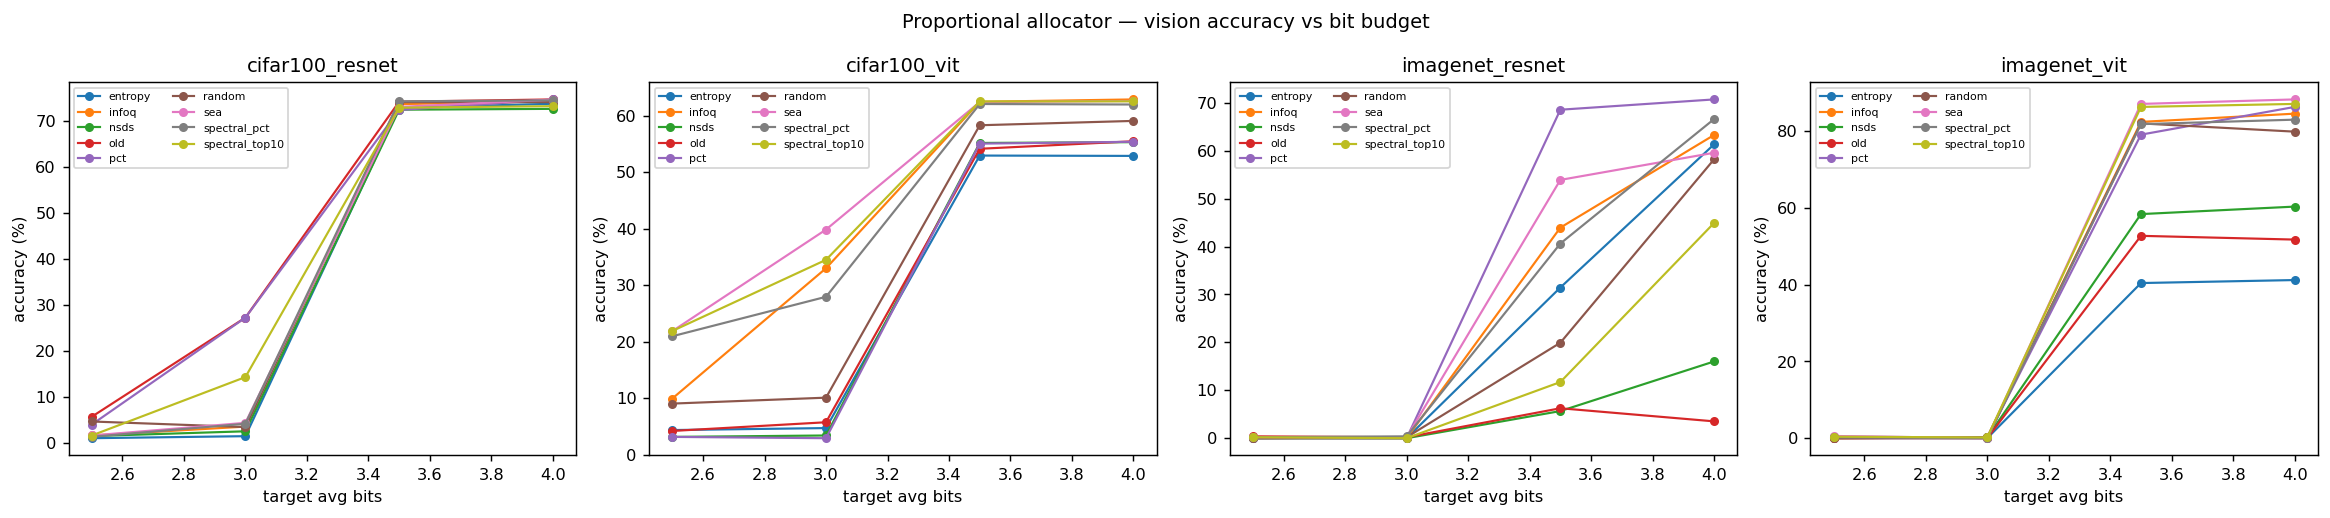

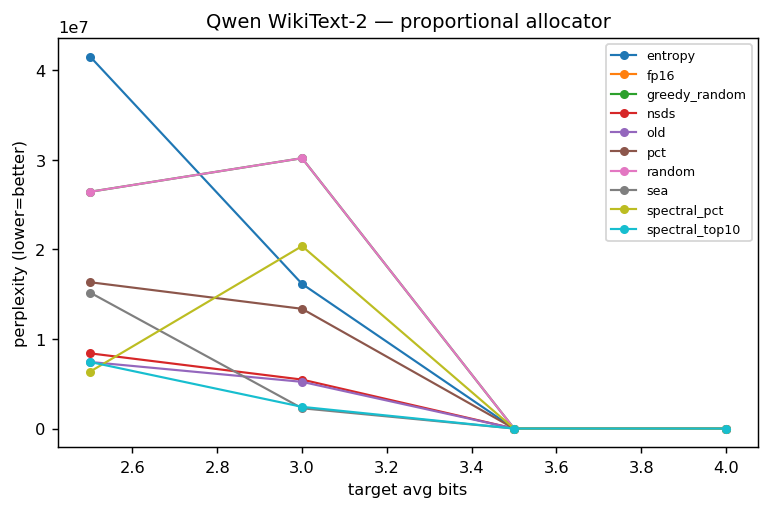


Best method per benchmark (vision=accuracy↑, qwen=ppl↓):
  cifar100_resnet    @ 2.5 → old            (5.73%, avg_bits=2.50)
  cifar100_resnet    @ 3.0 → pct            (27.28%, avg_bits=3.00)
  cifar100_resnet    @ 3.5 → spectral_pct   (74.28%, avg_bits=3.51)
  cifar100_resnet    @ 4.0 → pct            (74.69%, avg_bits=4.00)
  cifar100_vit       @ 2.5 → spectral_top10 (21.89%, avg_bits=2.52)
  cifar100_vit       @ 3.0 → sea            (39.83%, avg_bits=3.02)
  cifar100_vit       @ 3.5 → spectral_top10 (62.49%, avg_bits=3.52)
  cifar100_vit       @ 4.0 → infoq          (62.85%, avg_bits=4.01)
  imagenet_resnet    @ 2.5 → old            (0.39%, avg_bits=2.52)
  imagenet_resnet    @ 3.0 → spectral_pct   (0.39%, avg_bits=3.02)
  imagenet_resnet    @ 3.5 → pct            (68.55%, avg_bits=3.51)
  imagenet_resnet    @ 4.0 → pct            (70.70%, avg_bits=4.01)
  imagenet_vit       @ 2.5 → sea            (0.59%, avg_bits=2.52)
  imagenet_vit       @ 3.0 → greedy_random  (0.20%, avg_bits=3

In [13]:
# ── Combined comparison plots ─────────────────────────────────────────────────

from IPython.display import display

all_dfs = []
if 'cifar100_all' in dir() and len(cifar100_all):
    v = cifar100_all.copy()
    v['metric'] = 'accuracy'
    v['metric_value'] = v['accuracy']
    all_dfs.append(v)
if 'imagenet_all' in dir() and len(imagenet_all):
    v = imagenet_all.copy()
    v['metric'] = 'accuracy'
    v['metric_value'] = v['accuracy']
    all_dfs.append(v)
if len(qwen_df):
    q = qwen_df.copy()
    q['metric'] = 'perplexity'
    q['metric_value'] = q['perplexity']
    all_dfs.append(q)

if not all_dfs:
  print('No results yet — run benchmark cells above.')
else:
    combined = pd.concat(all_dfs, ignore_index=True)
    combined.to_csv(OUT_DIR / 'all_allocator_results.csv', index=False)

    # Vision accuracy vs target for each benchmark
    vis = combined[combined['metric'] == 'accuracy']
    benchmarks = sorted(vis['benchmark'].unique())
    if benchmarks:
        fig, axes = plt.subplots(1, len(benchmarks), figsize=(4.5 * len(benchmarks), 4), sharey=False)
        if len(benchmarks) == 1:
            axes = [axes]
        for ax, bench in zip(axes, benchmarks):
            sub = vis[(vis['benchmark'] == bench) & vis['method'].isin(METHODS + ['uniform_mixed'] + [f'uniform_int{b}' for b in VISION_BITS_LOW])]
            for method, g in sub.groupby('method'):
                g = g.sort_values('target_avg_bits')
                ax.plot(g['target_avg_bits'], g['metric_value'] * 100, marker='o', ms=4, lw=1.2, label=method)
            ax.set_title(bench)
            ax.set_xlabel('target avg bits')
            ax.set_ylabel('accuracy (%)')
            ax.legend(fontsize=6, ncol=2)
        fig.suptitle('Proportional allocator — vision accuracy vs bit budget')
        fig.tight_layout()
        fig.savefig(OUT_DIR / 'vision_accuracy_vs_budget.png', bbox_inches='tight')
        plt.show()

    # Qwen perplexity
    qw = combined[combined['metric'] == 'perplexity']
    if len(qw):
        fig, ax = plt.subplots(figsize=(6, 4))
        for method, g in qw.groupby('method'):
            g = g.sort_values('target_avg_bits')
            ax.plot(g['target_avg_bits'], g['metric_value'], marker='o', ms=4, lw=1.2, label=method)
        ax.set_xlabel('target avg bits')
        ax.set_ylabel('perplexity (lower=better)')
        ax.set_title('Qwen WikiText-2 — proportional allocator')
        ax.legend(fontsize=7)
        fig.tight_layout()
        fig.savefig(OUT_DIR / 'qwen_ppl_vs_budget.png', bbox_inches='tight')
        plt.show()

    # Headline: best method per benchmark @ each target
    print('\nBest method per benchmark (vision=accuracy↑, qwen=ppl↓):')
    for bench in combined['benchmark'].unique():
        bsub = combined[combined['benchmark'] == bench]
        higher_better = bsub['metric'].iloc[0] == 'accuracy'
        targets_for = QWEN_TARGET_AVG_BITS if bench == 'qwen_wikitext2' else TARGET_AVG_BITS
        for t in targets_for:
            tsub = bsub[bsub['target_avg_bits'] == t]
            tsub = tsub[~tsub['method'].str.startswith('uniform') & (tsub['method'] != 'fp32') & (tsub['method'] != 'fp16')]
            if tsub.empty:
                continue
            if higher_better:
                best = tsub.loc[tsub['metric_value'].idxmax()]
            else:
                best = tsub.loc[tsub['metric_value'].idxmin()]
            val = best['metric_value']
            disp = f'{val*100:.2f}%' if higher_better else f'{val:.2f}'
            print(f'  {bench:18s} @ {t} → {best["method"]:14s} ({disp}, avg_bits={best["avg_bits"]:.2f})')
